<a href="https://colab.research.google.com/github/23bobe/Helio_Work/blob/main/helio_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import scipy.stats as stats
p = 10/8_000
stats.norm.ppf(1-p)
median_key

np.float64(4.225)

In [1]:
%cd /content/drive/MyDrive/WIPAC/
!pip install healpy
import sys
import importlib
sys.path.append("home/rjtom/Projects/Heliosphere/")
import constants as const
importlib.reload(const)

mean = 250_000_000
nside = 8
lmax = 3 * nside
matrix_path = f'home/rjtom/Projects/scripts/COUNT_MATRIX_{nside}.h5'

fake_map = const.GET_FAKE(nside)

/content/drive/MyDrive/WIPAC
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 61.5 MB/s eta 0:00:00


In [2]:
import os
import sys
import importlib
import math
import numpy as np
import healpy as hp
from tqdm import tqdm
from scipy.interpolate import UnivariateSpline as unispline

sys.path.append("home/rjtom/Projects/Heliosphere/")
import constants as const
importlib.reload(const)

fix = 0.0

def get_fix(single=''):

  global median_key
  fake_map = const.GET_FAKE(nside)

  if single == '':
    base_matrices = [
        (prob, const.calc_matrix(eng, nside, filepath=matrix_path))
        for eng, prob in const.GAUSS_DICT.items()
        ]

    b_stack = np.stack([b for _, b in base_matrices])       # (n_energy, npix, npix)
    probs   = np.array([p for p, _ in base_matrices])
    map_fwd_pois = np.tensordot(probs, b_stack, axes=([0], [0]))
  if single == 'single':
    map_fwd_pois = const.calc_matrix(median_key, nside, filepath=matrix_path)

  map_earth_raw = np.dot(map_fwd_pois, fake_map)

  data = []

  for i in range(1000):
    while True:
      skymap = hp.synfast(hp.anafast(fake_map), nside)
      map_earth = np.dot(map_fwd_pois, skymap)
      if np.mean((map_earth_raw - map_earth)**2)**(1/2) >= 0.0007:
        continue
      else:
        break
    m = remove_m_zero(map_earth, nside)
    diff = (map_earth - m) / max(abs(m))
    data.append(diff)

  mean = np.mean(data, axis=0)

  x = np.arange(len(mean))

  # 2. Compute percentile approximations
  cp = 0.682689492137086 * 100
  p16 = np.percentile(data, 50.0 - cp / 2.0, axis=0)  # 1-sigma lower
  p84 = np.percentile(data, 50.0 + cp / 2.0, axis=0)  # 1-sigma upper

  sigma_y = (p84 - p16) / 2.0
  sigma_y = np.maximum(sigma_y, 1e-12)

  return unispline(x, mean, w=1/sigma_y, s=120)

def remove_m_zero(full_map, nside):
    lmax = 3 * nside - 1
    alm = hp.map2alm(full_map, lmax = lmax)
    l, m = hp.Alm.getlm(lmax=lmax)
    alm[m == 0] = 0
    return hp.alm2map(alm, nside = nside)

def correction(m_orig, theta, phi):
    """Add a small dipole correction aligned with (lon_deg, lat_deg) to m_orig."""
    vec_target = hp.ang2vec(theta, phi)
    vec_pixels = hp.pix2vec(nside, np.arange(len(m_orig)))
    dipole_map = -max(m_orig) / 10 * np.dot(vec_target, vec_pixels)
    if len(dipole_map) == 1:
      dipole_map = dipole_map[0]
    corr = m_orig + dipole_map
    return max(m_orig) * (corr / max(corr))

def fit_circle(mask_map, grad_map=None):
    """
    Fits a circle of radius pi/2 to highlighted pixels in a HEALPix map.
    """
    npix = len(mask_map)
    nside = hp.npix2nside(npix)

    # Extract non-zero masked pixels
    pix_indices = np.where(mask_map > 0)[0]

    # Use gradient intensity as weights if available
    weights = grad_map[pix_indices] if grad_map is not None else mask_map[pix_indices]

    # Convert pixel indices to 3D unit vectors
    x, y, z = hp.pix2vec(nside, pix_indices)
    vecs = np.column_stack([x, y, z])  # Shape: (N, 3)

    # Compute weighted scatter matrix M = sum(w_i * r_i * r_i^T)
    M = np.einsum('i,ij,ik->jk', weights, vecs, vecs)

    # Find eigenvalues and eigenvectors
    eigvals, eigvecs = np.linalg.eigh(M)

    # Center vector corresponds to the smallest eigenvalue
    center_vec = eigvecs[:, np.argmin(eigvals)]

    # Get spherical coordinates (theta in [0, pi], phi in [0, 2*pi])
    theta_center, phi_center = hp.vec2ang(center_vec)

    # If the center points to the right side (phi < pi / 180°), flip it to the left side
    if phi_center < np.pi:
        center_vec = -center_vec
        theta_center, phi_center = hp.vec2ang(center_vec)

    return center_vec, theta_center, phi_center

def run_reconstruction(map, single=''):
  past_t = np.inf
  past_p = np.inf
  t = -np.inf
  p = -np.inf
  converg = np.radians(1)
  max_num = 20
  global fix
  if not isinstance(fix,unispline):
    fix = get_fix(single)
  return map + fix(np.arange(len(map))) * max(abs(map))
  # while (abs(t - past_t) > converg or abs(p - past_p) > converg) and max_num != 0:
  #   max_num -= 1
  #   past_t = t
  #   past_p = p
  #   nside = int(np.sqrt(len(map) / 12))
  #   lmax = 3*nside-1
  #   alm = hp.map2alm(map, lmax=lmax)
  #   map_out, d_theta, d_phi = hp.alm2map_der1(alm, nside=nside, lmax=lmax)
  #   npix = hp.nside2npix(nside)
  #   theta, phi = hp.pix2ang(nside, np.arange(npix))
  #   grad = (d_theta**2 + d_phi**2)
  #   grad_c = grad.copy()
  #   low_value = min(grad) / 100
  #   grad[~((theta >= np.pi / 2) & (phi <= np.pi) & (phi > 0)) | (grad < 0.6 * (max(grad) - min(grad)) + min(grad))] = low_value
  #   arr, t, p = fit_circle(grad, grad_c)
  #   new_map = map.copy()
  #   new_map[hp.ang2pix(nside,t,p)] = max(new_map)
  #   const.plot_skymap(new_map, 'Grad Mask Fit')
  #   map = correction(map, t, p)
  # return map

# -------------------------------------------------------------------------
# Configuration & Setup
# -------------------------------------------------------------------------
nside = 8
mean = 250_000_000
lmax = 3 * nside
n_iterations = 500  # Number of Monte Carlo iterations
matrix_path = f'home/rjtom/Projects/scripts/COUNT_MATRIX_{nside}.h5'

fake_map = const.GET_FAKE(nside)
ls_full = np.arange(3 * nside)
npix = hp.nside2npix(nside)

data_types = ['no_m', 'recon']
cross_bools = [True, False]
single_types = ['', 'single']

data = data_types[:1]
cross_bool = cross_bools[1]
save = True
earth_error = True
single = single_types[1]

# -------------------------------------------------------------------------
# 1. Base Forward Propagation (Used for Signal Generation Only)
# -------------------------------------------------------------------------
cls_poisson_runs = np.zeros((n_iterations, lmax))
cls_poisson_flu_runs = np.zeros((n_iterations, lmax))
cls_earth_runs = np.zeros((n_iterations, lmax))
cls_earth_flu_runs = np.zeros((n_iterations, lmax))

cls_iso_noise_runs = np.zeros((n_iterations, lmax))
cls_iso_noise_flu_runs = np.zeros((n_iterations, lmax))

cls_cross_runs = []

cls_m_zero_runs = []
cls_m_zero_flu_runs = []
cls_m_zero_earth_runs = []
cls_m_zero_earth_flu_runs = []

cls_recon_runs = []
cls_recon_flu_runs = []
cls_recon_earth_flu_runs = []
cls_recon_earth_runs = []

if cross_bool:
    cls_cross_runs = np.zeros((n_iterations, lmax))
if 'no_m' in data:
    cls_m_zero_runs = np.zeros((n_iterations, lmax))
    cls_m_zero_flu_runs = np.zeros((n_iterations, lmax))
    cls_m_zero_earth_runs = np.zeros((n_iterations, lmax))
    cls_m_zero_earth_flu_runs = np.zeros((n_iterations, lmax))
if 'recon' in data:
    cls_recon_runs = np.zeros((n_iterations, lmax))
    cls_recon_flu_runs = np.zeros((n_iterations, lmax))
    cls_recon_earth_flu_runs = np.zeros((n_iterations, lmax))
    cls_recon_earth_runs = np.zeros((n_iterations, lmax))

median_key = 0
map_fwd = np.zeros((len(fake_map), len(fake_map)))
map_bwd = np.zeros((len(fake_map), len(fake_map)))

if single == '':
  for eng, prob in const.GAUSS_DICT.items():
      map_fwd += prob * const.calc_matrix(eng, nside, filepath=matrix_path)
elif single == 'single':
  sorted_keys = sorted(const.GAUSS_DICT.keys())
  n = len(sorted_keys)
  median_key = sorted_keys[(n - 1) // 2]
  map_fwd = const.calc_matrix(median_key, nside, filepath=matrix_path)

mean_k = const.get_k(mean, ('',single))
last_k = const.get_k(-1, ('',single))

if 'no_m' in data:
  last_k_m0 = const.get_k(-1, ('m0',single))
  mean_k_m0 = const.get_k(mean, ('m0',single))

if 'recon' in data:
  last_k_recon = const.get_k(-1, ('recon',single), run_reconstruction)
  mean_k_recon = const.get_k(mean, ('recon',single), run_reconstruction)


# -------------------------------------------------------------------------
# 2. Monte Carlo Loop (Signal + Noise vs. Pure Isotropic Noise vs. m=0 Removed)
# -------------------------------------------------------------------------

# --- Track 1: Signal + Noise ---
rng = np.random.default_rng()
for i in tqdm(range(n_iterations)):
    if single == '':
      base_matrices = [
          (prob, const.calc_matrix(eng, nside, filepath=matrix_path, pois = True))
          for eng, prob in const.GAUSS_DICT.items()
          ]

      b_stack = np.stack([b for _, b in base_matrices])       # (n_energy, npix, npix)
      probs   = np.array([p for p, _ in base_matrices])
      map_fwd_pois = np.tensordot(probs, b_stack, axes=([0], [0]))
    elif single == 'single':
      map_fwd_pois = const.calc_matrix(median_key, nside, filepath=matrix_path, pois=True)
    map_earth = np.dot(map_fwd_pois, fake_map)
    map_fwd_base = np.dot(map_fwd, fake_map)

    cls_earth = hp.anafast(map_earth, lmax=lmax-1)
    cls_earth_runs[i] = cls_earth

    if 'no_m' in data:
        map_m_zero_earth = remove_m_zero(map_earth, nside)
        cls_m_zero_earth = hp.anafast(map_m_zero_earth, lmax=lmax-1)
        cls_m_zero_earth_runs[i] = cls_m_zero_earth
    if 'recon' in data:
        map_recon_earth = run_reconstruction(map_m_zero_earth)
        cls_recon_earth = hp.anafast(map_recon_earth, lmax=lmax-1)
        cls_recon_earth_runs[i] = cls_recon_earth

    if earth_error:
        map_fwd_base_flu = rng.poisson((map_earth + 1) * mean)
        map_fwd_base_flu = (map_fwd_base_flu / np.mean(map_fwd_base_flu)) - 1
        cls_earth_flu = hp.anafast(map_fwd_base_flu, lmax=lmax-1)
        cls_earth_flu_runs[i] = cls_earth_flu

        if 'no_m' in data:
          map_m_zero_earth_flu = remove_m_zero(map_fwd_base_flu, nside)
          cls_m_zero_earth_flu = hp.anafast(map_m_zero_earth_flu, lmax=lmax-1)
          cls_m_zero_earth_flu_runs[i] = cls_m_zero_earth_flu

        if 'recon' in data:
          map_recon_earth_flu = run_reconstruction(map_m_zero_earth_flu)
          cls_recon_earth_flu = hp.anafast(map_recon_earth_flu, lmax=lmax-1)
          cls_recon_earth_flu_runs[i] = cls_recon_earth_flu

        map_fwd_base_flu = rng.poisson((map_fwd_base + 1) * mean)
        map_fwd_base_flu = (map_fwd_base_flu / np.mean(map_fwd_base_flu)) - 1

        if 'no_m' in data:
          map_m_zero_flu = remove_m_zero(map_fwd_base_flu, nside)

        if 'recon' in data:
          map_recon_flu = run_reconstruction(map_m_zero_flu)

    map_fwd_noisy = map_fwd_base

    if 'no_m' in data:
        map_m_zero = remove_m_zero(map_fwd_noisy, nside)

    if 'recon' in data:
        map_recon = run_reconstruction(map_m_zero)

    if earth_error:
        map_fwd_noisy_flu = map_fwd_base_flu

    U, S, Vt = np.linalg.svd(map_fwd_pois, full_matrices=False)
    Ut_ear = U.T @ map_fwd_noisy
    Ut_ear_flu = U.T @ map_fwd_noisy_flu
    map_bwd = np.zeros(fake_map.shape, dtype=float)
    map_bwd_flu = np.zeros(fake_map.shape, dtype=float)

    if 'no_m' in data:
      Ut_ear_m0 = U.T @ map_m_zero
      Ut_ear_m0_flu = U.T @ map_m_zero_flu
      map_bwd_m0 = np.zeros(fake_map.shape, dtype=float)
      map_bwd_m0_flu = np.zeros(fake_map.shape, dtype=float)
    if 'recon' in data:
      Ut_ear_recon = U.T @ map_recon
      Ut_ear_recon_flu = U.T @ map_recon_flu
      map_bwd_recon = np.zeros(fake_map.shape, dtype=float)
      map_bwd_recon_flu = np.zeros(fake_map.shape, dtype=float)

    for k, s in enumerate(S[:int(last_k)+1]):
        map_bwd = map_bwd + (Ut_ear[k] / s) * Vt[k]
        if k <= mean_k:
          map_bwd_flu = map_bwd_flu + (Ut_ear_flu[k] / s) * Vt[k]

        if 'no_m' in data:
          if k <= last_k_m0:
            map_bwd_m0 = map_bwd_m0 + (Ut_ear_m0[k] / s) * Vt[k]
          if k <= mean_k_m0:
            map_bwd_m0_flu = map_bwd_m0_flu + (Ut_ear_m0_flu[k] / s) * Vt[k]

        if 'recon' in data:
          if k <= last_k_recon:
            map_bwd_recon = map_bwd_recon + (Ut_ear_recon[k] / s) * Vt[k]
          if k <= mean_k_recon:
            map_bwd_recon_flu = map_bwd_recon_flu + (Ut_ear_recon_flu[k] / s) * Vt[k]

    if earth_error:
        cls_poisson_flu = hp.anafast(map_bwd_flu, lmax=lmax-1)
        cls_poisson_flu_runs[i] = cls_poisson_flu

        if 'no_m' in data:
          cls_m_zero_flu = hp.anafast(map_bwd_m0_flu, lmax=lmax-1)
          cls_m_zero_flu_runs[i] = cls_m_zero_flu

        if 'recon' in data:
          cls_recon_flu = hp.anafast(map_bwd_recon_flu, lmax=lmax-1)
          cls_recon_flu_runs[i] = cls_recon_flu

    cls_poisson = hp.anafast(map_bwd, lmax=lmax-1)
    cls_poisson_runs[i] = cls_poisson

    if 'no_m' in data:
      cls_m_zero = hp.anafast(map_bwd_m0, lmax=lmax-1)
      cls_m_zero_runs[i] = cls_m_zero

    if 'recon' in data:
      cls_recon = hp.anafast(map_bwd_recon, lmax=lmax-1)
      cls_recon_runs[i] = cls_recon

    if cross_bool:
        cls_cross = hp.anafast(map_bwd, fake_map) / np.sqrt(hp.anafast(map_bwd) * hp.anafast(fake_map))
        cls_cross_runs[i] = cls_cross

    # --- Track 2: Pure Isotropic Noise Baseline ---
    map_bwd_iso_noisy = fake_map - map_bwd
    if earth_error:
        map_bwd_iso_noisy_flu = fake_map - map_bwd_flu
        cls_iso_noise_flu = hp.anafast(map_bwd_iso_noisy_flu, lmax=lmax-1)
        cls_iso_noise_flu_runs[i] = cls_iso_noise_flu

    cls_iso_noise = hp.anafast(map_bwd_iso_noisy, lmax=lmax-1)
    cls_iso_noise_runs[i] = cls_iso_noise

    # --- Track 3: Signal (m=0 Removed) + Noise Pathway ---

def save_data(v, filename, to_save, extra = False):
    global single
    if to_save:
        b, ext, = os.path.splitext(filename)
        counter = 1
        filename = os.path.join(base, f"{b}_{counter}{ext}")
        while os.path.exists(filename):
            if not extra:
                filename = os.path.join(base, f"{b}{'' if len(single) == 0 else f'_single'}_{counter}{ext}")
            else:
                filename = os.path.join(base, f"{b}{'' if len(single) == 0 else f'_single'}_flu_{counter}{ext}")
            counter += 1
        if counter >= 50:
            if not extra:
                filename = os.path.join(base, f"{b}{'' if len(single) == 0 else f'_single'}_{np.random.default_rng().integers(1,51)}{ext}")
            else:
                filename = os.path.join(base, f"{b}{'' if len(single) == 0 else f'_single'}_flu_{np.random.default_rng().integers(1,51)}{ext}")
        np.save(filename, v)

base = 'home/rjtom/monte_carlo'
if np.any(cls_poisson_runs):
    v = cls_poisson_runs
    filename = 'poisson.npy'
    save_data(v, filename, save)
    if np.any(cls_poisson_flu_runs):
        v = cls_poisson_flu_runs
        save_data(v, filename, save, True)
if np.any(cls_earth_runs):
    v = cls_earth_runs
    filename = 'earth.npy'
    save_data(v, filename, save)
    if np.any(cls_earth_flu_runs):
        v = cls_earth_flu_runs
        save_data(v, filename, save, True)
if np.any(cls_m_zero_earth_runs):
    v = cls_m_zero_earth_runs
    filename = 'mear.npy'
    save_data(v, filename, save)
    if np.any(cls_m_zero_earth_flu_runs):
        v = cls_m_zero_earth_flu_runs
        save_data(v, filename, save, True)
if np.any(cls_recon_earth_runs):
    v = cls_recon_earth_runs
    filename = 'rear.npy'
    save_data(v, filename, save)
    if np.any(cls_recon_earth_flu_runs):
        v = cls_recon_earth_flu_runs
        save_data(v, filename, save, True)
if np.any(cls_cross_runs):
    v = cls_cross_runs
    filename = 'cross.npy'
    save_data(v, filename, save)
if np.any(cls_iso_noise_runs):
    v = cls_iso_noise_runs
    filename = 'iso.npy'
    save_data(v, filename, save)
    if np.any(cls_iso_noise_flu_runs):
        v = cls_iso_noise_flu_runs
        save_data(v, filename, save, True)
if np.any(cls_m_zero_runs):
    v = cls_m_zero_runs
    filename = 'm0.npy'
    save_data(v, filename, save)
    if np.any(cls_m_zero_flu_runs):
        v = cls_m_zero_flu_runs
        save_data(v, filename, save, True)
if np.any(cls_recon_runs):
    v = cls_recon_runs
    filename = 'recon.npy'
    save_data(v, filename, save)
    if np.any(cls_recon_flu_runs):
        v = cls_recon_flu_runs
        save_data(v, filename, save, True)

  0%|          | 2/500 [00:07<32:48,  3.95s/it]


KeyboardInterrupt: 

--- Loaded Files Summary ---

Single Plot:
  home/rjtom/monte_carlo/poisson_1.npy
  home/rjtom/monte_carlo/iso_1.npy
  home/rjtom/monte_carlo/m0_1.npy


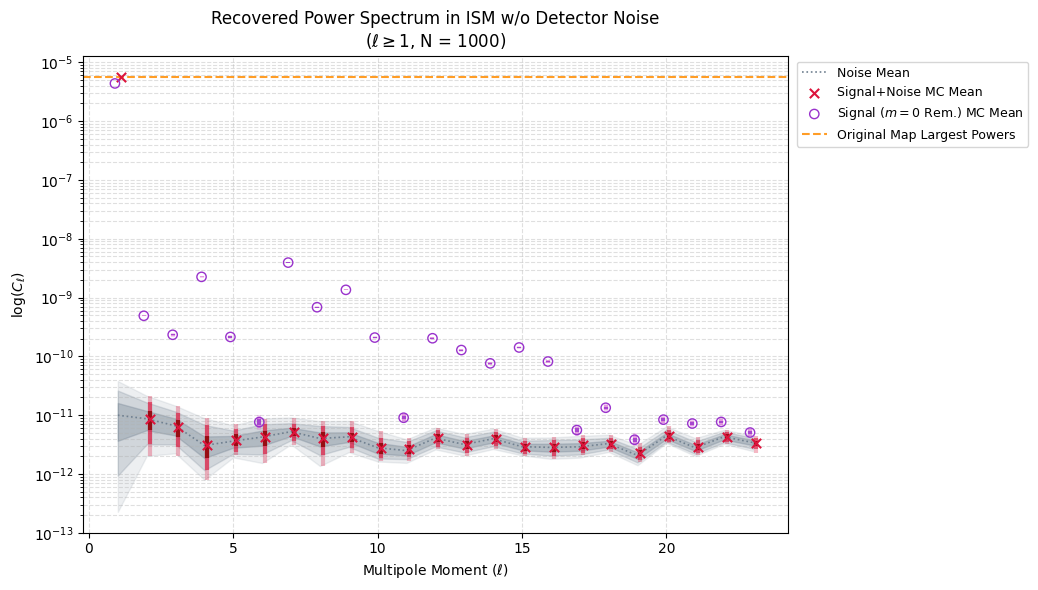

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import importlib
import healpy as hp

sys.path.append("home/rjtom/Projects/Heliosphere/")
import constants as const
importlib.reload(const)

iso_min = 1.0
single = ''
data = data_types[:1]

# -------------------------------------------------------------------------
# 1. Config & Data Helpers
# -------------------------------------------------------------------------
grid_view = False  # Set to False to render a single individual plot

# Individual plot settings (only used if grid_view = False)
single_earth_map = False
single_earth_error = False

def load_data(name, extra):
    global single
    root_directory = "home/rjtom/monte_carlo"
    combined_content = []
    loaded_files = []

    for root, dirs, files in os.walk(root_directory):
        for file in files:
            full_path = os.path.join(root, file)
            if not extra:
                if name in full_path and 'flu' not in full_path and single in full_path:
                  if single == '' and 'single' in full_path:
                    continue
                  combined_content.extend(np.load(full_path))
                  loaded_files.append(full_path)
            else:
                if name in full_path and 'flu' in full_path and single in full_path:
                  if single == '' and 'single' in full_path:
                    continue
                  combined_content.extend(np.load(full_path))
                  loaded_files.append(full_path)
    return combined_content, loaded_files

fake_map = const.GET_FAKE(nside)
cls_fake_map_full = hp.anafast(fake_map)
dipole_power_fake = np.max(hp.anafast(fake_map))
percents = [0.13498980316, 2.27501319482, 15.865525393, 84.134474606, 97.7249868052, 99.8650101968]

# -------------------------------------------------------------------------
# 2. Single Subplot Generator Function
# -------------------------------------------------------------------------
def render_panel(ax, earth_map, earth_error):
    panel_files = []

    def fetch_data(name, extra):
        data, files = load_data(name, extra)
        panel_files.extend(files)
        return data

    # Load Data
    if not earth_map:
        cls_poisson_runs = fetch_data('poisson', earth_error)
        cls_cross_runs = fetch_data('cross', earth_error) if cross_bool else []
        cls_iso_noise_runs = fetch_data('iso', earth_error)
        cls_m_zero_runs = fetch_data('m0', earth_error) if 'no_m' in data else []
        cls_m_recon_runs = fetch_data('recon', earth_error) if 'recon' in data else []
    else:
        cls_poisson_runs = fetch_data('earth', earth_error)
        cls_m_zero_runs = fetch_data('mear', earth_error) if 'no_m' in data else []
        cls_m_recon_runs = fetch_data('rear', earth_error) if 'recon' in data else []
        cls_cross_runs, cls_iso_noise_runs = [], []

    # Strip Monopole (l=0)
    ls_full = np.arange(lmax)
    ls = ls_full[1:]
    cls_poisson_runs = np.array(cls_poisson_runs)[:, 1:]

    if cross_bool and len(cls_cross_runs) > 0:
        cls_cross_runs = np.array(cls_cross_runs)[:, 1:]
    if len(cls_iso_noise_runs) > 0:
        cls_iso_noise_runs = np.array(cls_iso_noise_runs)[:, 1:]
    if 'no_m' in data and len(cls_m_zero_runs) > 0:
        cls_m_zero_runs = np.array(cls_m_zero_runs)[:, 1:]
    if 'recon' in data and len(cls_m_recon_runs) > 0:
        cls_m_recon_runs = np.array(cls_m_recon_runs)[:, 1:]

    # Calculate Percentiles
    mean_poi = np.mean(cls_poisson_runs, axis=0)
    poi_low3, poi_low2, poi_low1, poi_high1, poi_high2, poi_high3 = np.percentile(cls_poisson_runs, percents, axis=0)

    if 'no_m' in data and len(cls_m_zero_runs) > 0:
        mean_m_zero = np.mean(cls_m_zero_runs, axis=0)
        m_zero_low3, m_zero_low2, m_zero_low1, m_zero_high1, m_zero_high2, m_zero_high3 = np.percentile(cls_m_zero_runs, percents, axis=0)

    if 'recon' in data and len(cls_m_recon_runs) > 0:
        mean_m_recon = np.mean(cls_m_recon_runs, axis=0)
        m_recon_low3, m_recon_low2, m_recon_low1, m_recon_high1, m_recon_high2, m_recon_high3 = np.percentile(cls_m_recon_runs, percents, axis=0)

    if len(cls_iso_noise_runs) > 0:
        mean_iso = np.mean(cls_iso_noise_runs, axis=0)
        iso_low3, iso_low2, iso_low1, iso_high1, iso_high2, iso_high3 = np.percentile(cls_iso_noise_runs, percents, axis=0)

    # Render Elements
    if not earth_map and len(cls_iso_noise_runs) > 0:
        ax.fill_between(ls, iso_low3, iso_high3, color='slategray', alpha=0.12, label=r'_Noise 3$\sigma$ Envelope')
        ax.fill_between(ls, iso_low2, iso_high2, color='slategray', alpha=0.22, label=r'_Noise 2$\sigma$ Envelope')
        ax.fill_between(ls, iso_low1, iso_high1, color='slategray', alpha=0.32, label=r'_Noise 1$\sigma$ Envelope')
        ax.plot(ls, mean_iso, color='slategray', linestyle=':', linewidth=1.2, label='Noise Mean')

    x_offset = 0.1 if len(data) == 1 else 0.2
    pois_offset = x_offset if len(data) == 1 else 0.0

    ax.errorbar(ls + pois_offset, mean_poi, yerr=(mean_poi - poi_low3, poi_high3 - mean_poi), fmt='none', color='crimson', elinewidth=3.0, alpha=0.3, label=r'_Signal+Noise 3$\sigma$')
    ax.errorbar(ls + pois_offset, mean_poi, yerr=(mean_poi - poi_low2, poi_high2 - mean_poi), fmt='none', color='crimson', elinewidth=3.0, alpha=0.6, label=r'_Signal+Noise 2$\sigma$')
    ax.errorbar(ls + pois_offset, mean_poi, yerr=(mean_poi - poi_low1, poi_high1 - mean_poi), fmt='none', color='darkred', elinewidth=3.0, alpha=0.8, label=r'_Signal+Noise 1$\sigma$')
    ax.scatter(ls + pois_offset, mean_poi, color='crimson', marker='x', s=45, zorder=6, label='Signal+Noise MC Mean')

    if 'no_m' in data and len(cls_m_zero_runs) > 0:
        ax.errorbar(ls - x_offset, mean_m_zero, yerr=(mean_m_zero - m_zero_low3, m_zero_high3 - mean_m_zero), fmt='none', color='orchid', elinewidth=3.0, alpha=0.3, label=r'_Signal ($m=0$ Rem.) 3$\sigma$')
        ax.errorbar(ls - x_offset, mean_m_zero, yerr=(mean_m_zero - m_zero_low2, m_zero_high2 - mean_m_zero), fmt='none', color='orchid', elinewidth=3.0, alpha=0.6, label=r'_Signal ($m=0$ Rem.) 2$\sigma$')
        ax.errorbar(ls - x_offset, mean_m_zero, yerr=(mean_m_zero - m_zero_low1, m_zero_high1 - mean_m_zero), fmt='none', color='darkorchid', elinewidth=3.0, alpha=0.8, label=r'_Signal ($m=0$ Rem.) 1$\sigma$')
        ax.scatter(ls - x_offset, mean_m_zero, facecolors = 'none', edgecolors='darkorchid', marker='o', s=45, zorder=6, label='Signal ($m=0$ Rem.) MC Mean')

    if 'recon' in data and len(cls_m_recon_runs) > 0:
        ax.errorbar(ls + x_offset, mean_m_recon, yerr=(mean_m_recon - m_recon_low3, m_recon_high3 - mean_m_recon), fmt='none', color='cyan', elinewidth=3.0, alpha=0.3, label=r'_Signal ($m=0$ Recon.) 3$\sigma$')
        ax.errorbar(ls + x_offset, mean_m_recon, yerr=(mean_m_recon - m_recon_low2, m_recon_high2 - mean_m_recon), fmt='none', color='cyan', elinewidth=3.0, alpha=0.6, label=r'_Signal ($m=0$ Recon.) 2$\sigma$')
        ax.errorbar(ls + x_offset, mean_m_recon, yerr=(mean_m_recon - m_recon_low1, m_recon_high1 - mean_m_recon), fmt='none', color='darkcyan', elinewidth=3.0, alpha=0.8, label=r'_Signal ($m=0$ Recon.) 1$\sigma$')
        ax.scatter(ls + x_offset, mean_m_recon, facecolors = 'none', edgecolors='darkcyan', marker='o', s=45, zorder=6, label='Signal ($m=0$ Recon.) MC Mean')

    ax.axhline(y=dipole_power_fake, color='darkorange', linestyle='--', linewidth=1.5, alpha=0.85, zorder=2, label=r'Original Map Largest Powers')

    ax.set_yscale('log')
    if len(cls_iso_noise_runs) > 0:
        global iso_min
        # iso_min = min(iso_min, np.min(iso_low3) * 0.1)
        iso_min = 10e-14
        ax.set_ylim(bottom=iso_min)

    ax.set_xlabel(r'Multipole Moment ($\ell$)')
    ax.set_ylabel(r'log($C_\ell$)')
    title_loc = 'on Earth' if earth_map else 'in ISM'
    title_err = 'w/ Detector Noise' if earth_error else 'w/o Detector Noise'
    ax.set_title(f'Recovered Power Spectrum {title_loc} {title_err}\n' + r'($\ell \geq 1$' + f', N = {len(cls_poisson_runs)})', fontsize=11 if grid_view else 12)
    ax.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1) if not grid_view else None, fontsize=8 if grid_view else 9)

    return panel_files

# -------------------------------------------------------------------------
# 3. Execution Control
# -------------------------------------------------------------------------
if grid_view:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
    panel_labels = ["Top-Left", "Top-Right", "Bottom-Left", "Bottom-Right"]
    combinations = [
        (False, False), (False, True),
        (True, False),  (True, True)
    ]

    print("--- Loaded Files Summary ---")
    for label, ax, (e_map, e_err) in zip(panel_labels, axes.flat, combinations):
        files_used = render_panel(ax, e_map, e_err)
        print(f"\n{label}:")
        if files_used:
            for filepath in files_used:
                print(f"  {filepath}")
        else:
            print("  No files loaded.")

    subtitle = "Recovered Power Spectrum Comparison Across Map Locations & Detector Errors"
    if single == 'single':
      subtitle += f" at {10**median_key / 1000:.2f} TeV"
    else:
      subtitle += " over IceCube 10 TeV Distribution"
    plt.suptitle(subtitle, fontsize=14, y=0.99)
else:
    fig, ax = plt.subplots(figsize=(11, 6))
    files_used = render_panel(ax, single_earth_map, single_earth_error)

    print("--- Loaded Files Summary ---")
    print("\nSingle Plot:")
    if files_used:
        for filepath in files_used:
            print(f"  {filepath}")
    else:
        print("  No files loaded.")

plt.tight_layout()
plt.savefig('/content/ism_earth_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Work on circle fit
# COrrecting code for HAWK IceCube example: Try using alm2map to upscale map to higher nside
# Change dipole to guassian point and try cosine to power
# Do repeat loop of ISM ot ISM loop to see if there is deteriation
# See if there are trends in the differences between predicted recover to actual or a method to recover more accurate predictions

In [ ]:
!rm -rf home/rjtom/monte_carlo/*
%pwd

'Emptied'

<Figure size 1000x600 with 0 Axes>

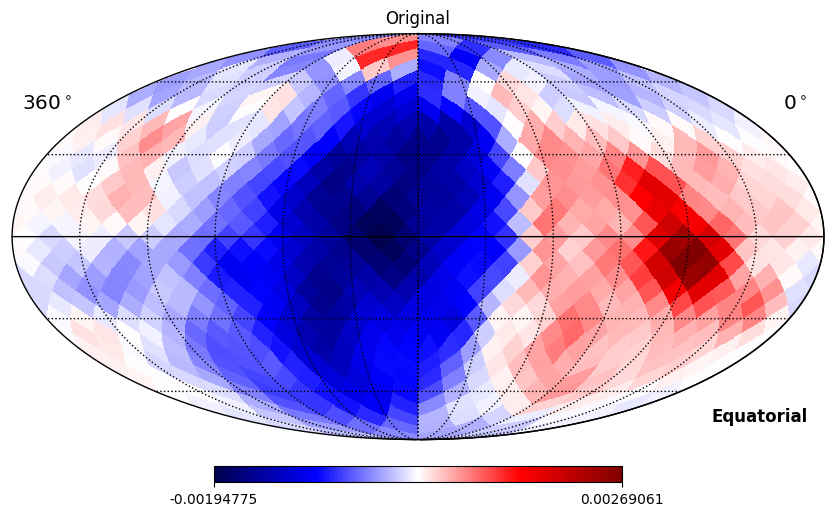

<Figure size 1000x600 with 0 Axes>

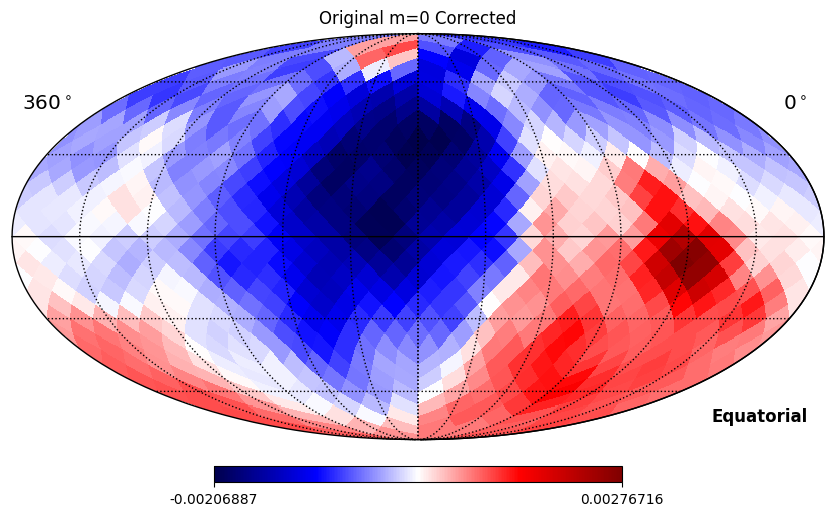

14


<Figure size 1000x600 with 0 Axes>

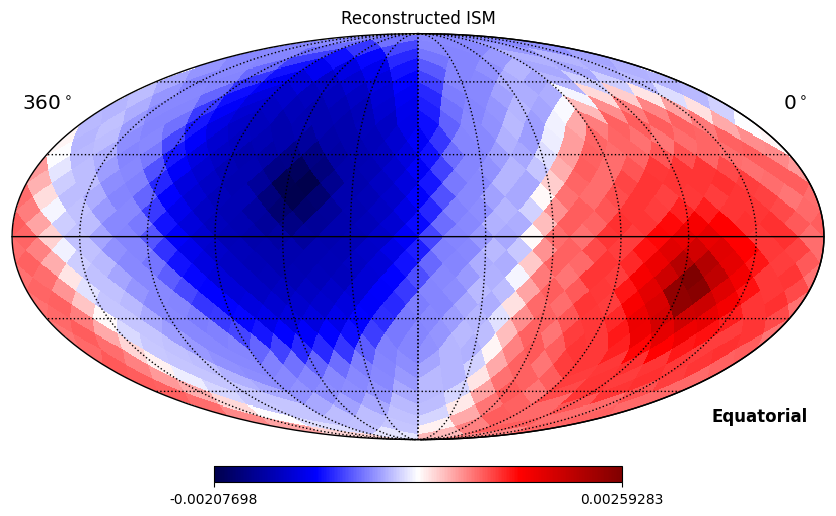

<Figure size 1000x600 with 0 Axes>

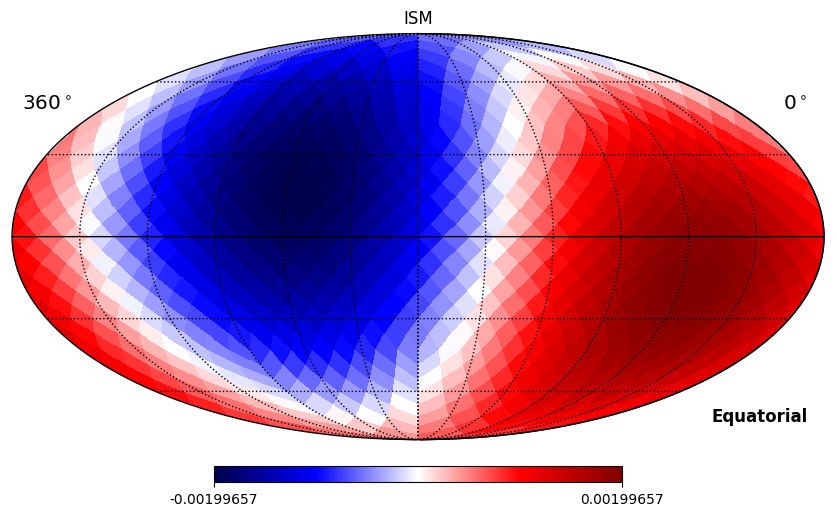

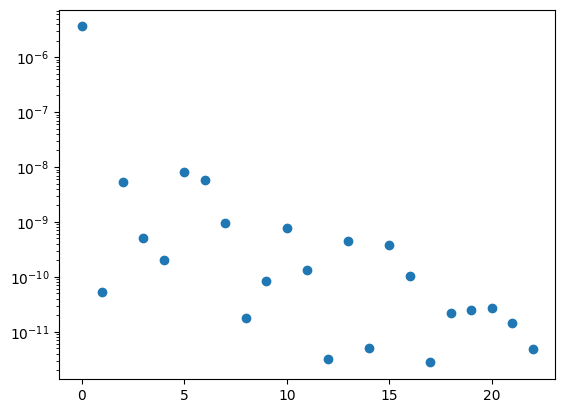

<Figure size 1000x600 with 0 Axes>

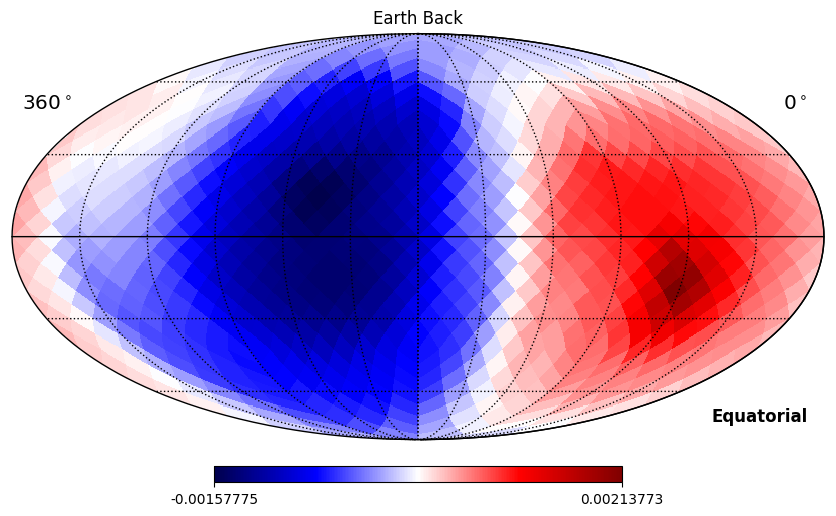

<Figure size 1000x600 with 0 Axes>

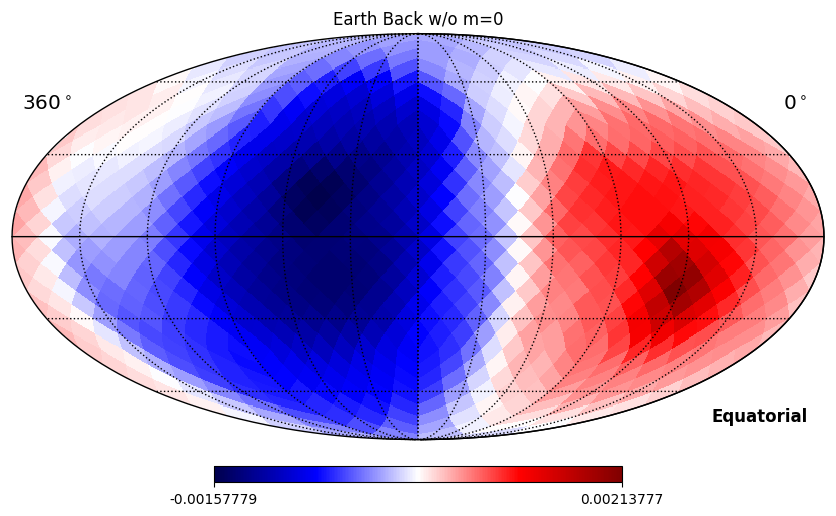

<Figure size 1000x600 with 0 Axes>

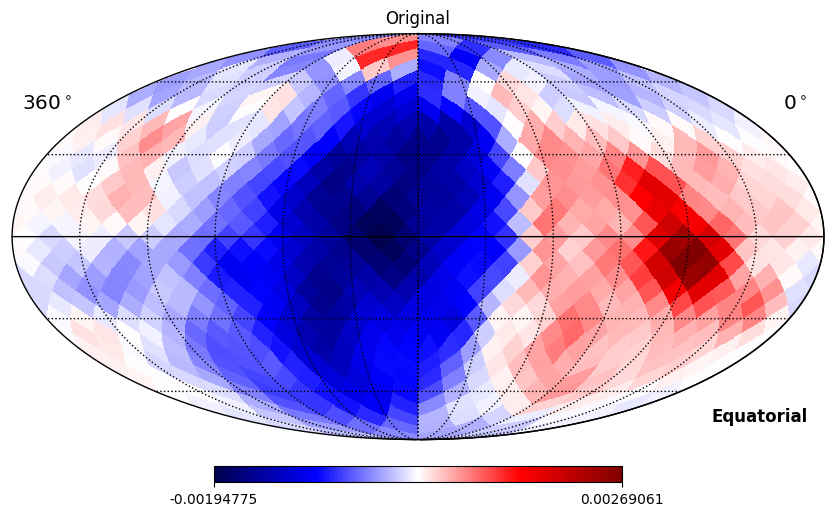

In [ ]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
def read_alm(txt, lmin=1,lmax=14, scale=1e-4, nside=None):

    idx11= hp.sphtfunc.Alm.getidx(lmax = lmax, l=1, m=1)
    alm = np.zeros(hp.sphtfunc.Alm.getsize(lmax),dtype=complex)

    for row in txt.splitlines():
        if not row: #skip empty lines
            continue
        row = row.replace(" ","")
        col = row.split(",")
        ell = int(col[0])
        if ell > lmax: break
        for i in range(len(col[1:])):
            idx = hp.sphtfunc.Alm.getidx(lmax = lmax, l=ell, m=i+1)
            alm[idx]=complex(col[i+1])*scale

    if nside:
        return hp.alm2map(alm, nside)

    return alm

text = """
1,-13.26+10.49j
2,-0.21-3.6j,-7.20+2.05j
3,1.75-1.7j,-2.03+0.13j,0.20+0.17j
4,1.70-0.52j,0.07+1.69j,-0.86-0.8j,-1.19+0.04j
5,0.58+0.27j,-0.07-1.1j,-1.64-0.051j,0.18-0.15j,-0.11-1.5j
6,0.80-0.88j,-0.24-0.38j,-0.10+0.63j,0.13-1.2j,0.27+0.47j,1.65-0.53j
7,0.44-0.67j,0.37+0.15j,-0.21-0.14j,-0.70+0.04j,0.84-0.27j,0.13-0.54j,0.07+0.91j
8,0.26+0.06j,0.14-0.47j,-0.39-0.22j,-0.42+0.72j,-0.15-0.15j,-0.72-0.61j,0.42+0.36j,-0.54+0.19j
9,0.11-0.88j,-0.29-1.3j,0.22-0.17j,0.12-0.56j,-0.01-0.34j,0.60+0.47j,-0.06-0.48j,0.15+0.64j,-0.04+0.45j
10,0.21-0.97j,0.25-0.5j,0.21-0.65j,0.09-0.088j,-0.10+0.12j,0.11-0.017j,0.02+0.19j,0.22+0.12j,-0.66-0.57j,-0.26+0.38j
11,0.56-0.39j,0.06-0.42j,-0.15-0.68j,-0.04+0.05j,-0.26+0.04j,-0.07-0.26j,-0.16+0.25j,0.25+0.02j,-0.21-0.4j,0.15-0.25j,-0.06-0.18j
12,0.40+0.07j,0.19-0.56j,-0.27-0.48j,-0.17-0.1j,-0.13-0.18j,-0.03-0.23j,0.33+0.13j,0.37+0.09j,-0.46+0.25j,-0.13+0.20j,-0.08+0.21j,0.04-0.18j
13,0.45-0.33j,-0.04-0.69j,0.17-0.92j,-0.26-0.6j,0.13+0.24j,-0.08+0.02j,0.04+0.04j,0.11+0.13j,0.13-0.13j,-0.35-0.098j,0.39+0.45j,-0.01-0.3j,0.41-0.17j
14,0.57-0.16j,0.13-0.53j,0.17-1.1j,-0.31-0.089j,0.08-0.09j,-0.25-0.12j,-0.05+0.22j,-0.13+0.34j,0.36-0.11j,-0.04-0.072j,-0.11-0.17j,-0.19+0.32j,0.13+0.21j,0.18+0.35j
"""

base_matrices = [
    (prob, const.calc_matrix(eng, nside, filepath=matrix_path))
    for eng, prob in const.GAUSS_DICT.items()
    ]

b_stack = np.stack([b for _, b in base_matrices])       # (n_energy, npix, npix)
probs   = np.array([p for p, _ in base_matrices])
map_fwd_pois = np.tensordot(probs, b_stack, axes=([0], [0]))

skymap = read_alm(text, lmin=1,lmax=14,scale=1e-4, nside=8)
const.plot_skymap(skymap,"Original")

skymap_m = run_reconstruction(skymap)

const.plot_skymap(skymap_m, "Original m=0 Corrected")

U, S, Vt = np.linalg.svd(map_fwd_pois, full_matrices=False)
Ut_ear_recon_flu = U.T @ skymap_m
map_bwd_recon_flu = np.zeros(fake_map.shape, dtype=float)

ks = const.get_k(250_000_000, ('recon', ''))
print(k)
for k, s in enumerate(S[:ks]):
    map_bwd_recon_flu = map_bwd_recon_flu + (Ut_ear_recon_flu[k] / s) * Vt[k]
const.plot_skymap(map_bwd_recon_flu, 'Reconstructed ISM')
const.plot_skymap(fake_map, 'ISM')
ana = hp.anafast(map_bwd_recon_flu)[1:]
plt.scatter(np.arange(len(ana)), ana)
plt.yscale('log')

map_earth = np.dot(map_fwd_pois, map_bwd_recon_flu)
map_earth = remove_m_zero(map_earth, nside)
const.plot_skymap(map_earth, 'Earth Back')
map_earth = remove_m_zero(map_earth, nside)
const.plot_skymap(map_earth, 'Earth Back w/o m=0')
const.plot_skymap(skymap,"Original")

100%|██████████| 1000/1000 [09:44<00:00,  1.71it/s]


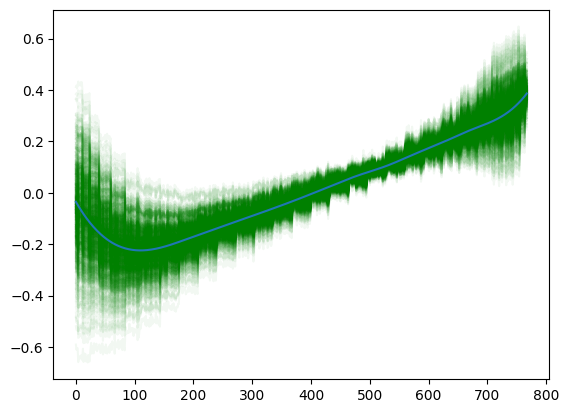

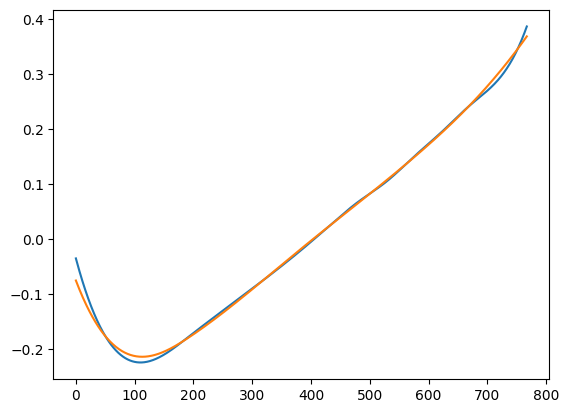

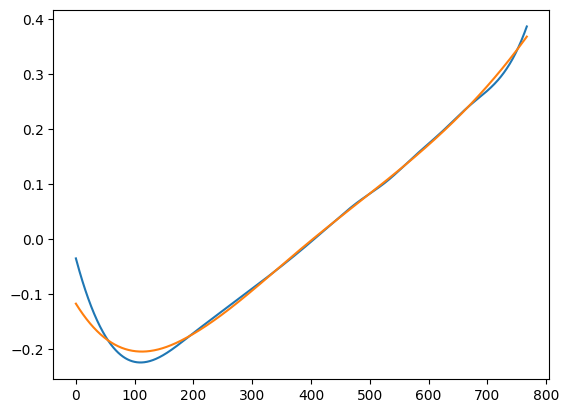

<Figure size 640x480 with 0 Axes>

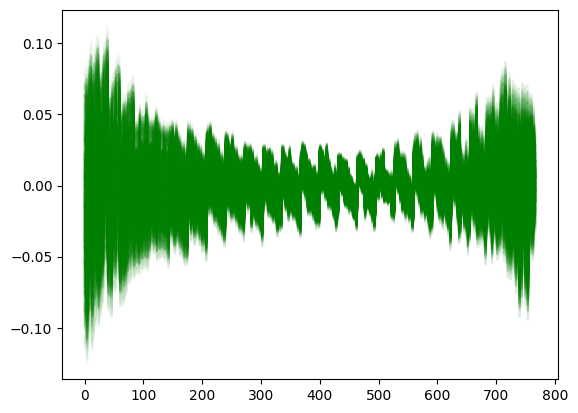

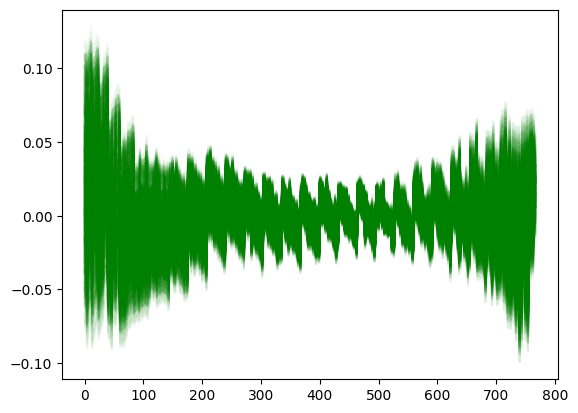

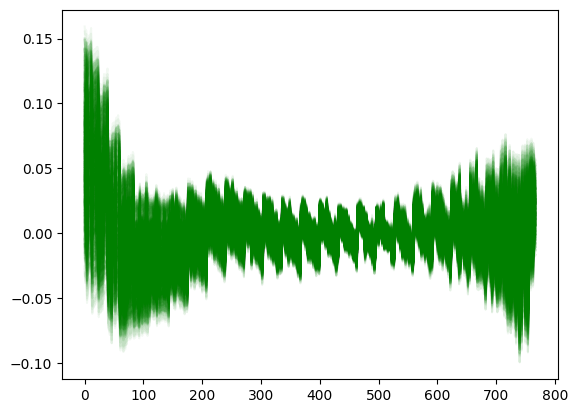

In [ ]:
from astropy.units.si import mA
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from tqdm import tqdm

def to_get():

  fake_map = const.GET_FAKE(nside)

  mean = 250_000_000

  base_matrices = [
      (prob, const.calc_matrix(eng, nside, filepath=matrix_path))
      for eng, prob in const.GAUSS_DICT.items()
      ]

  b_stack = np.stack([b for _, b in base_matrices])       # (n_energy, npix, npix)
  probs   = np.array([p for p, _ in base_matrices])
  map_fwd_pois = np.tensordot(probs, b_stack, axes=([0], [0]))
  map_earth_raw = np.dot(map_fwd_pois, fake_map)

  min_pix = np.argmin(map_earth_raw)
  theta,phi = hp.pix2ang(nside, min_pix)
  step = 1

  data = []
  pixs = []

  for i in tqdm(range(1000)):
    while True:
      skymap = hp.synfast(hp.anafast(fake_map), nside)
      map_earth = np.dot(map_fwd_pois, skymap)
      if np.mean((map_earth_raw - map_earth)**2)**(1/2) >= 0.0007:
        continue
      else:
        break
    # print(np.mean((map_earth_raw - map_earth)**2)**(1/2))
    # const.plot_skymap(map_earth, 'Earth')
    m = remove_m_zero(map_earth, nside)
    diff = (map_earth - m) / max(abs(m))
    data.append(diff)
    plt.plot(np.arange(len(diff)), diff, color='green', alpha=0.05)

  mean = np.mean(data, axis=0)

  x = np.arange(len(mean))

  # 2. Compute percentile approximations
  cp = 0.682689492137086 * 100
  p16 = np.percentile(data, 50.0 - cp / 2.0, axis=0)  # 1-sigma lower
  p84 = np.percentile(data, 50.0 + cp / 2.0, axis=0)  # 1-sigma upper

  sigma_y = (p84 - p16) / 2.0
  sigma_y = np.maximum(sigma_y, 1e-12)

  return unispline(x, mean, w=1/sigma_y, s=120)
spline, spl, sp = to_get()
x = np.arange(len(fake_map))
plt.plot(x, spline(x))
plt.figure()
plt.plot(x, spline(x))
plt.plot(x, spl(x))
plt.figure()
plt.plot(x, spline(x))
plt.plot(x, sp(x))
plt.figure()

base_matrices = [
    (prob, const.calc_matrix(eng, nside, filepath=matrix_path))
    for eng, prob in const.GAUSS_DICT.items()
    ]

b_stack = np.stack([b for _, b in base_matrices])       # (n_energy, npix, npix)
probs   = np.array([p for p, _ in base_matrices])
map_fwd_pois = np.tensordot(probs, b_stack, axes=([0], [0]))
map_earth_raw = np.dot(map_fwd_pois, fake_map)
data = []
fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()
fig3, ax3 = plt.subplots()

for i in tqdm(range(1000)):
    while True:
        skymap = hp.synfast(hp.anafast(fake_map), nside)
        map_earth = np.dot(map_fwd_pois, skymap)

        # Calculate RMSE efficiently
        rmse = np.sqrt(np.mean((map_earth_raw - map_earth)**2))
        if rmse < 0.0001:
            break

    m = remove_m_zero(map_earth, nside)
    max_map_earth = max(abs(map_earth))
    max_m = max(abs(m))

    # 2. Plot onto the corresponding axis for each spline fit
    # Plot 1: spline(x)
    y1 = (map_earth - (m + spline(x) * max_m)) / max_map_earth
    ax1.plot(x, y1, color='green', alpha=0.05)

    # Plot 2: spl(x)
    y2 = (map_earth - (m + spl(x) * max_m)) / max_map_earth
    ax2.plot(x, y2, color='green', alpha=0.05)

    # Plot 3: sp(x)
    y3 = (map_earth - (m + sp(x) * max_m)) / max_map_earth
    ax3.plot(x, y3, color='green', alpha=0.05)
# cp = 0.682689492137086 * 100
# p16 = np.percentile(data, 50.0 - cp / 2.0, axis=0)  # 1-sigma lower
# p84 = np.percentile(data, 50.0 + cp / 2.0, axis=0)  # 1-sigma upper
# plt.ylim(min(p16)*0.9, max(p84)*1.1)
plt.show()

[  0. 192. 288. 336. 384. 408. 432. 456. 480. 492. 504. 516. 528. 540.
 552. 564. 576. 600. 624. 672. 767.]


<Figure size 1000x600 with 0 Axes>

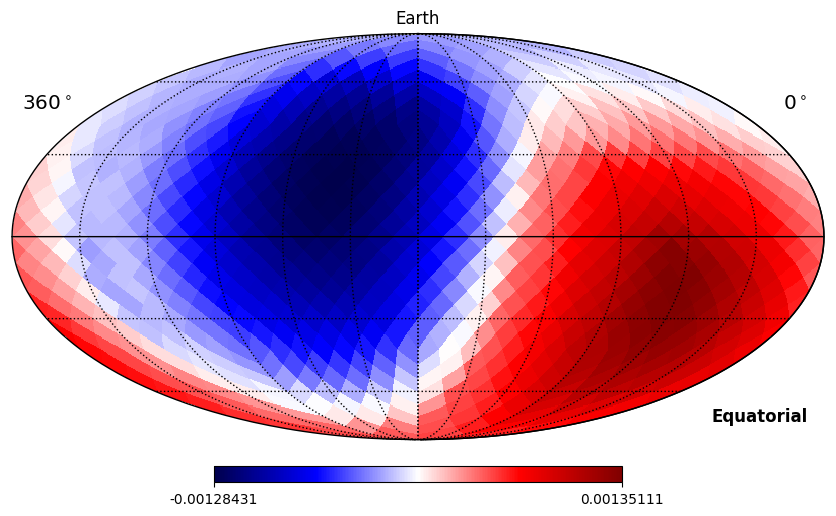

<Figure size 1000x600 with 0 Axes>

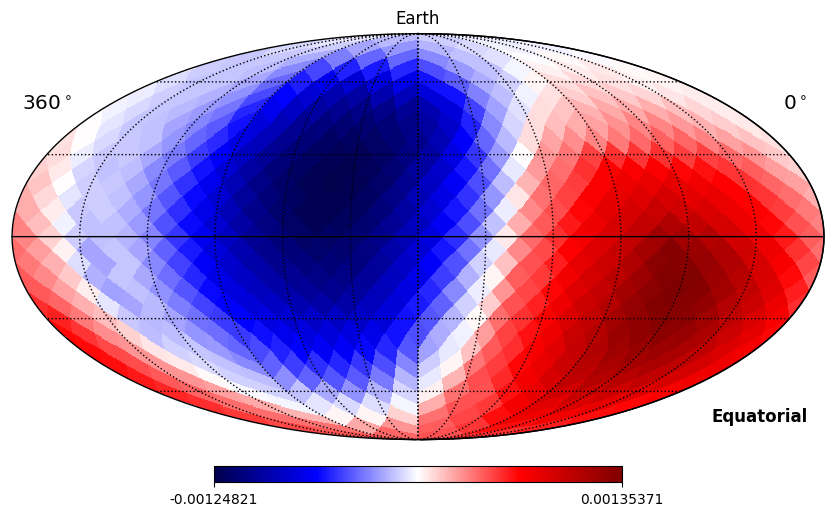

In [ ]:
print(fix.get_knots())
while True:
  skymap = hp.synfast(hp.anafast(fake_map), nside)
  map_earth = np.dot(map_fwd_pois, skymap)
  if np.mean((map_earth_raw - map_earth)**2)**(1/2) >= 0.0007:
    continue
  else:
    break
const.plot_skymap(map_earth, 'Earth')
m = remove_m_zero(map_earth, nside)
const.plot_skymap(m + fix(x) * max(abs(m)), 'Earth')

<Figure size 1000x600 with 0 Axes>

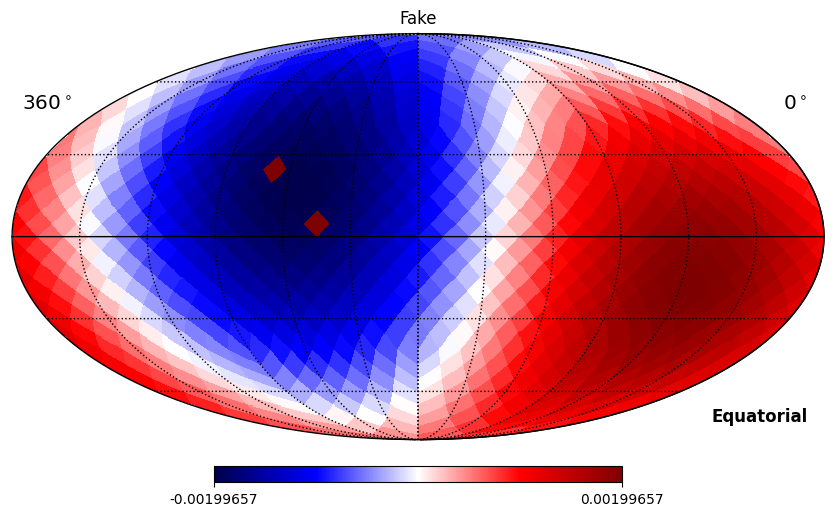

In [ ]:
f = const.GET_FAKE(nside)
min_pix = np.argmin(f)
theta,phi = hp.pix2ang(nside, min_pix)
# f[hp.ang2pix(nside,theta,phi)] = max(abs(f))
step = 10
for i in [-1, 1]:
  t = np.radians(np.degrees(theta)+i*step)
  p = np.radians(np.degrees(phi)-(i*step))
  pix = hp.ang2pix(nside,t,p)
  f[pix] = max(abs(f))
const.plot_skymap(f, 'Fake')

<Figure size 1000x600 with 0 Axes>

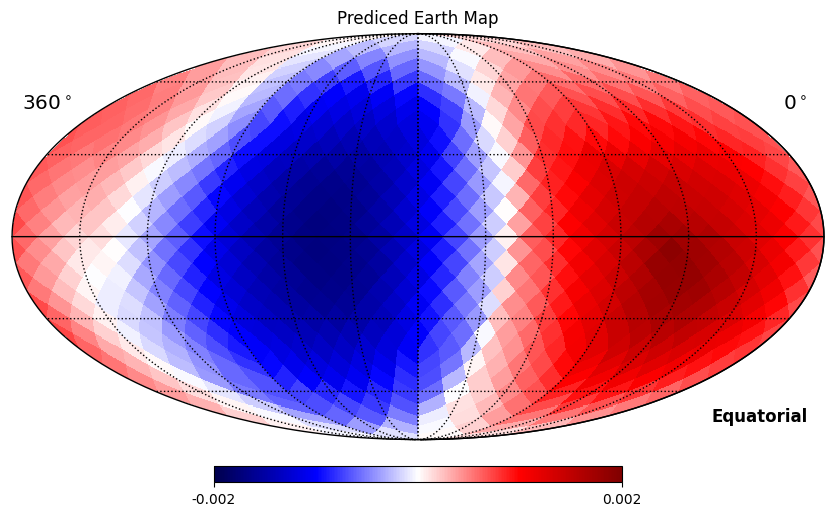

In [ ]:
import numpy as np

fake_map = const.GET_FAKE(nside)

base_matrices = [
    (prob, const.calc_matrix(eng, nside, filepath=matrix_path))
    for eng, prob in const.GAUSS_DICT.items()
    ]

b_stack = np.stack([b for _, b in base_matrices])       # (n_energy, npix, npix)
probs   = np.array([p for p, _ in base_matrices])
map_fwd_pois = np.tensordot(probs, b_stack, axes=([0], [0]))
map_earth = np.dot(map_fwd_pois, fake_map)
map_earth = remove_m_zero(map_earth, nside)
const.plot_skymap(map_earth, 'Prediced Earth Map', dMin = -0.002, dMax = 0.002)

Iteration 1: Pole Lon = 224.8587 ± 7.3290°, Pole Lat = 13.5782 ± 7.3290°, r = 90.0000° (fixed)
Iteration 2: Pole Lon = 224.4984 ± 7.3290°, Pole Lat = 13.7671 ± 7.3290°, r = 90.0000° (fixed)
Iteration 3: Pole Lon = 224.4984 ± 7.3290°, Pole Lat = 13.7671 ± 7.3290°, r = 90.0000° (fixed)


<Figure size 1000x600 with 0 Axes>

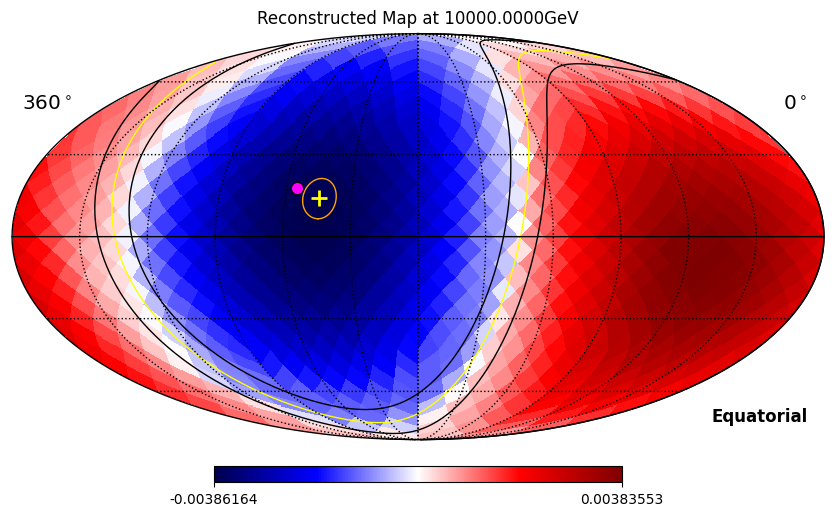

<Figure size 1000x600 with 0 Axes>

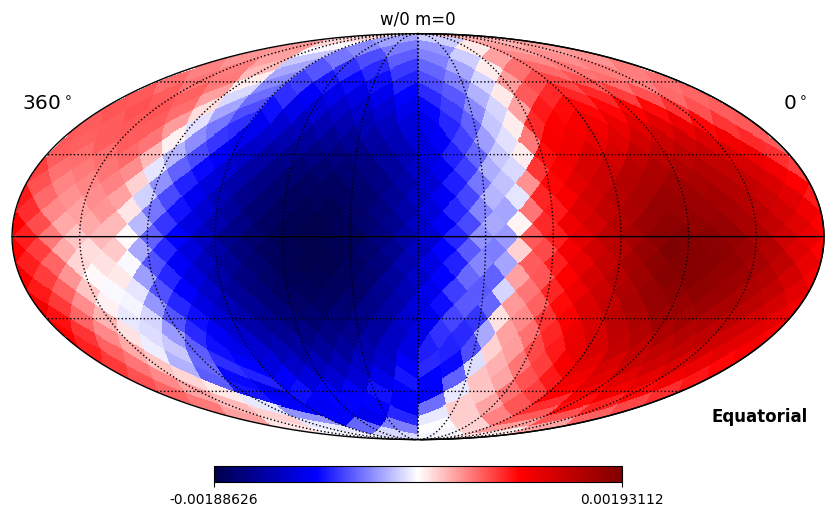

<Figure size 1000x600 with 0 Axes>

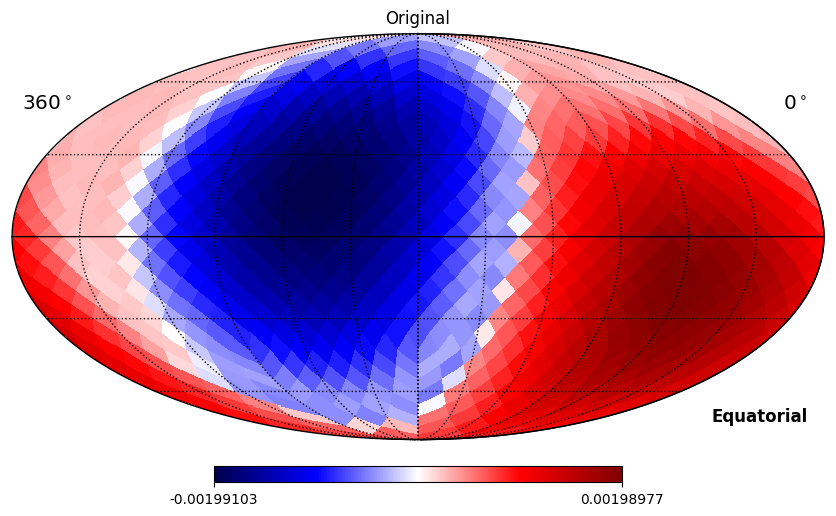

In [25]:
import sys
import glob
import os
import math
import numpy as np
import healpy as hp
from scipy.optimize import minimize
from PIL import Image
import matplotlib.pyplot as plt

sys.path.append("/home/rjtom/Projects/Heliosphere/")
import constants as const

NSIDE = 8

# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------

def remove_m_zero(m_map, nside):
    """Remove m=0 (zonal harmonic) components from a HEALPix map."""
    lmax = 3 * nside - 1
    alm = hp.map2alm(m_map, lmax=lmax)
    for l in range(lmax + 1):
        idx = hp.Alm.getidx(lmax, l, 0)
        alm[idx] = 0.0
    return hp.alm2map(alm, nside=nside)


def get_circle(lon, lat, r, num_pts=300):
    """Return (thetas, phis) for a circle on the sphere.

    Parameters
    ----------
    lon, lat : float
        Centre (pole) of the circle in degrees.
    r : float
        Angular radius in radians.
    num_pts : int
        Number of sample points along the circle.
    """
    phi   = np.radians(lon)
    theta = np.radians(90.0 - lat)   # colatitude

    circle_thetas = np.full(num_pts, r)
    circle_phis   = np.linspace(0, 2 * np.pi, num_pts)

    rot = hp.Rotator(deg=False, rot=[phi, -theta, 0], inv=True)
    return rot(circle_thetas, circle_phis)


def cost_function(params, map_data, nside, r=np.pi / 2.0):
    """Maximize the integrated gradient magnitude along the circle line.
    Since map_data is zeroed outside the target quadrant, summing edge values
    rewards circles whose 90-degree arc aligns directly along the red ridge."""
    lon, lat = params
    thetas, phis = get_circle(lon, lat, r, num_pts=300)
    edge_values  = hp.get_interp_val(map_data, thetas, phis)
    return -np.sum(edge_values)


def build_grad_sum_sq(m, nside, lon_range=(90, 180), lat_range=(-90, 0)):
    """Compute sum of squared gradient components masked to lower-right quadrant."""
    lmax = 3 * nside - 1
    alm = hp.map2alm(m, lmax=lmax)
    _, grad_theta, grad_phi = hp.alm2map_der1(alm, nside)

    grad_sq_sum = (grad_theta**2) + (grad_phi**2)

    lons, lats = hp.pix2ang(nside, np.arange(hp.nside2npix(nside)), lonlat=True)

    # Mask to lower-right quadrant
    mask = (lons >= lon_range[0]) & (lons <= lon_range[1]) & \
           (lats >= lat_range[0]) & (lats <= lat_range[1])

    grad_sq_sum[~mask] = 0.0
    return grad_sq_sum


def pixel_resolution(nside):
    """Angular pixel size in radians for a given NSIDE."""
    return hp.nside2resol(nside)


def fit_boundary_circle(grad_map, nside, initial_guesses=None):
    """Fit circle center (pole) for fixed radius r = pi/2 by searching globally
    for the center 90 degrees away that aligns the circle along the ridge."""
    r_fixed = np.pi / 2.0

    # Global search bounds for the pole position
    bounds = [(-180.0, 360.0), (-89.0, 89.0)]

    if initial_guesses is None:
        # Candidate poles ~90 deg away from lower-right quadrant
        initial_guesses = [
            (45.0, 35.0),
            (35.0, 45.0),
            (225.0, -35.0),
            (135.0, 45.0)
        ]

    best_res = None
    best_val = np.inf

    for guess in initial_guesses:
        res = minimize(
            cost_function,
            guess,
            args=(grad_map, nside, r_fixed),
            method="Nelder-Mead",
            tol=1e-8,
            bounds=bounds
        )
        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    lon, lat = best_res.x

    pix_rad        = pixel_resolution(nside)
    r_err          = pix_rad
    center_err_rad = pix_rad
    center_err_deg = np.degrees(pix_rad)

    return lon, lat, r_fixed, r_err, center_err_rad, center_err_deg


def get_error_rings(lon, lat, r, r_err, center_err_rad, num_pts=300):
    """Return point arrays for uncertainty bounds."""
    inner       = np.vstack(get_circle(lon, lat, max(0.0, r - r_err), num_pts=num_pts))
    outer       = np.vstack(get_circle(lon, lat, r + r_err,           num_pts=num_pts))
    center_ring = np.vstack(get_circle(lon, lat, center_err_rad,      num_pts=num_pts))
    return inner, outer, center_ring


def build_overlays(best_lon, best_lat, r, r_err, center_err_rad, num_pts=300):
    """Assemble overlay arrays and matching colors for skymap display."""
    best_fit = np.vstack(get_circle(best_lon, best_lat, r, num_pts=num_pts))
    inner, outer, center_ring = get_error_rings(
        best_lon, best_lat, r, r_err, center_err_rad, num_pts=num_pts
    )

    overlays = [best_fit,  inner,   outer,   center_ring]
    colors   = ["yellow",  "black", "black", "orange"]
    return overlays, colors


# def apply_dipole_correction(m_orig, nside, lon_deg, lat_deg):
#     """Add a dipole correction aligned with pole (lon_deg, lat_deg) to m_orig."""
#     theta = np.radians(abs(90.0 - lat_deg))
#     phi   = np.radians(lon_deg)

#     vec_target = hp.ang2vec(theta, phi)
#     vec_pixels = hp.pix2vec(nside, np.arange(hp.nside2npix(nside)))
#     dipole_map = -1e-3 * np.dot(vec_target, vec_pixels)

#     lmax       = 3 * nside - 1
#     dipole_alm = hp.map2alm(dipole_map, lmax=lmax)
#     m_alm      = hp.map2alm(m_orig.copy(), lmax=lmax)

#     monopole_dipole_idx = np.arange(lmax + 1)
#     m_alm[monopole_dipole_idx] += dipole_alm[monopole_dipole_idx]

#     return hp.alm2map(m_alm, nside=nside)

def apply_dipole_correction(m_orig, nside, lon_deg, lat_deg):
    vec_target = hp.ang2vec(lon_deg, lat_deg, lonlat=True)
    vec_pixels = hp.pix2vec(nside, np.arange(hp.nside2npix(nside)))
    dipole_map = -2e-3 * np.dot(vec_target, vec_pixels)
    return m_orig + dipole_map

def get_closest_pole(lon, lat, target_vec):
    """Return either (lon, lat) or its antipodal pole, whichever is closer to target_vec."""
    p1 = hp.ang2vec(np.radians(90.0 - lat), np.radians(lon)).ravel()
    p2 = -p1

    # Ensure target_p is a flat 1D vector of shape (3,)
    target_p = np.asarray(target_vec).ravel()
    if target_p.size != 3:
        target_lon, target_lat = hp.vec2ang(target_vec, lonlat=True)
        target_p = hp.ang2vec(np.radians(90.0 - target_lat), np.radians(target_lon)).ravel()

    if np.dot(p1, target_p) >= np.dot(p2, target_p):
        return lon, lat
    else:
        return (lon + 180.0) % 360.0, -lat


# ---------------------------------------------------------------------------
# Main Execution Loop
# ---------------------------------------------------------------------------

nside = NSIDE
os.makedirs(f"/home/rjtom/Projects/nside_{nside}", exist_ok=True)

for eng, _ in [(4, 0)]:
    orig_m = np.dot(map_fwd, fake_map)
    # Remove initial m=0 component
    orig = remove_m_zero(orig_m, nside)

    # Iterative circle fitting & dipole reconstruction
    CONVERGENCE_TOL = 1e-3
    prev_lon = -np.inf
    prev_lat = -np.inf
    best_lon = 45.0
    best_lat = 35.0
    iteration = 0
    m = orig.copy()
    past_coordinates = []

    while (abs(best_lon - prev_lon) > CONVERGENCE_TOL or
           abs(best_lat - prev_lat) > CONVERGENCE_TOL):

        prev_lon = best_lon
        prev_lat = best_lat

        # 1. Compute sum of square gradients
        grad_map = build_grad_sum_sq(m, nside)

        # 2. Fit optimal pole center for fixed r = pi/2
        current_guesses = [(best_lon, best_lat), (45.0, 35.0), (225.0, -35.0)]
        best_lon, best_lat, r, r_err, center_err_rad, center_err_deg = fit_boundary_circle(
            grad_map, nside, initial_guesses=current_guesses
        )

        disp_lon, disp_lat = get_closest_pole(best_lon, best_lat, const.B_VEC)

        overlays, colors = build_overlays(disp_lon, disp_lat, r, r_err, center_err_rad)

        # 3. Apply dipole correction aligned with fitted pole
        m = apply_dipole_correction(orig, nside, best_lon, best_lat)
        iteration += 1

        print(
            f"Iteration {iteration}: "
            f"Pole Lon = {best_lon:.4f} ± {center_err_deg:.4f}°, "
            f"Pole Lat = {best_lat:.4f} ± {center_err_deg:.4f}°, "
            f"r = {np.degrees(r):.4f}° (fixed)"
        )

        const.plot_skymap(
            grad_map,
            title=f"Gradient Square Fit Iteration:{iteration}",
            ovrlyd=overlays,
            ovrlyd_colors=colors,
            circ=True,
            center=[disp_lon, disp_lat],
            filename=f"/home/rjtom/Projects/nside_{nside}/magnetic_bound_{10**eng:.0f}_{iteration}.png",
            show=False,
            extra_point=hp.vec2ang(const.B_VEC, lonlat=True)
        )

        current_coord = (best_lon, best_lat)
        if current_coord in past_coordinates:
            cycle_start_idx = past_coordinates.index(current_coord)
            cycle_coords = past_coordinates[cycle_start_idx:]

            x_coords = [math.cos(np.radians(coord[0])) for coord in cycle_coords]
            y_coords = [math.sin(np.radians(coord[0])) for coord in cycle_coords]

            best_lon = np.degrees(math.atan2(sum(y_coords), sum(x_coords)))
            best_lat = sum(coord[1] for coord in cycle_coords) / len(cycle_coords)

            overlays, colors = build_overlays(disp_lon, disp_lat, r, r_err, center_err_rad)
            m = apply_dipole_correction(orig, nside, best_lon, best_lat)

            print(
                f"Average Result: "
                f"Pole Lon = {best_lon:.4f} ± {center_err_deg:.4f}°, "
                f"Pole Lat = {best_lat:.4f} ± {center_err_deg:.4f}°"
            )
            break

        past_coordinates.append(current_coord)

    plt.close('all')

    # Final skymap plot
    const.plot_skymap(
        m,
        title=f"Reconstructed Map at {10**eng:.4f}GeV",
        ovrlyd=overlays,
        ovrlyd_colors=colors,
        circ=True,
        center=[disp_lon, disp_lat],
        filename=f"/home/rjtom/Projects/nside_{nside}/magnetic_bound_{10**eng:.0f}_final.png",
        show=True,
        extra_point=hp.vec2ang(const.B_VEC, lonlat=True)
    )
    const.plot_skymap(remove_m_zero(orig_m, nside), 'w/0 m=0')
    const.plot_skymap(orig_m, 'Original')

<Figure size 1000x600 with 0 Axes>

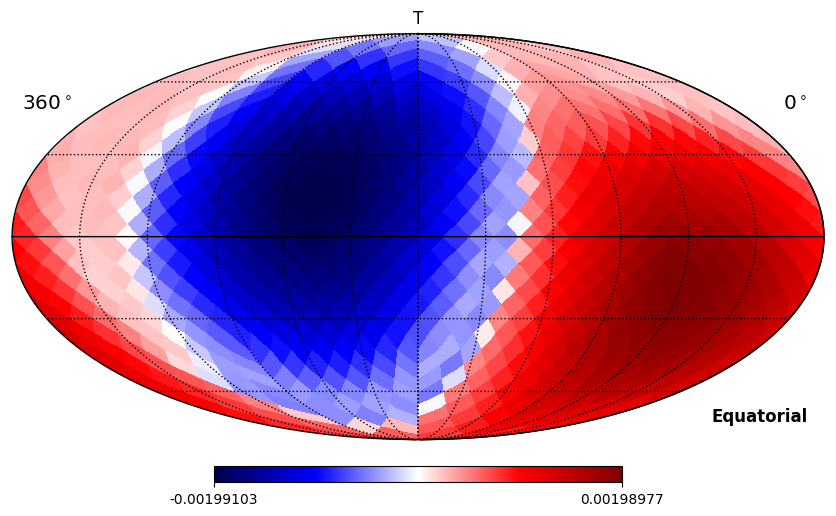

<Figure size 1000x600 with 0 Axes>

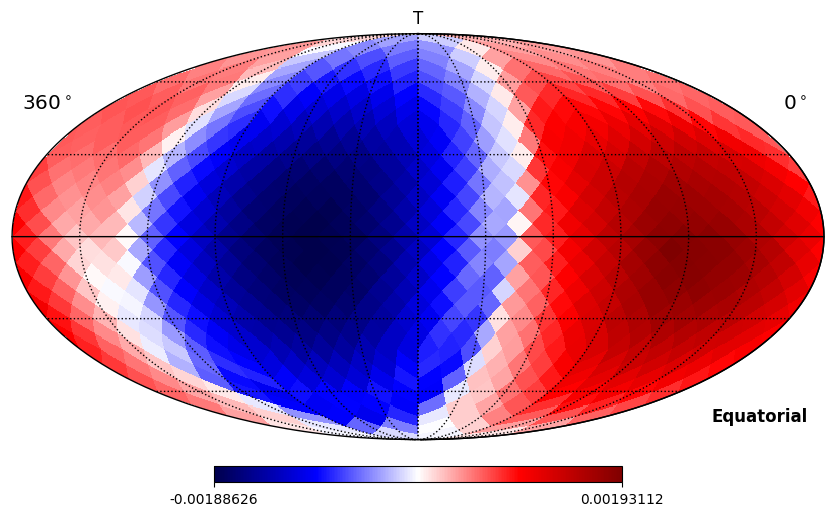

In [5]:
map_fwd_base = np.dot(map_fwd, fake_map)
const.plot_skymap(map_fwd_base,'T')
map = remove_m_zero(map_fwd_base, nside)
const.plot_skymap(map,'T')